# 05 — Cross-Generator Generalisation Evaluation

**Milestone 4** (July 6–20, 2026)

This notebook evaluates the CIFAKE-trained EfficientNet-B3 detector on images from five
progressively newer generator families:

| Family | Source | Type |
|--------|--------|------|
| StyleGAN | OwensLab/CommunityForensics-Eval (architecture=GAN) | GAN (older) |
| SD3/Flux | Rajarshi-Roy-research/Defactify_Image_Dataset (Label_B=SD3) | Modern diffusion |
| Midjourney v6 | Defactify_Image_Dataset (Label_B=Midjourney) | Proprietary diffusion |
| GPT-4o | Yejy53/GPT-ImgEval | Autoregressive hybrid |
| Janus-Pro | midbee/Janus-Pro-R1-Data (source=Janus-Pro-7B) | Autoregressive (newer) |

**Research hypothesis:** The detector relies on Stable Diffusion v1.4-specific texture
artifacts and will show degradation on **autoregressive** generators (GPT-4o, Janus-Pro),
not uniformly across all newer generators — diffusion/GAN families transfer well.

**Prerequisites:** Upload the CIFAKE zip file to `My Drive/ai-image-detection/` before running the setup cells below. All five generator families auto-download and stream without login (Janus-Pro images come from the ungated [midbee/Janus-Pro-R1-Data](https://huggingface.co/datasets/midbee/Janus-Pro-R1-Data), filtered to `source=Janus-Pro-7B`).

## 0. CIFAKE Setup

In [1]:
# Cell 1 — Mount Google Drive & define paths
import os
from google.colab import drive

drive.mount("/content/drive")

DRIVE_ROOT = "/content/drive/MyDrive/ai-image-detection"
REPO_DIR = "/content/ai-image-detection"
DATA_DIR = os.path.join(REPO_DIR, "data", "raw", "cifake")
CHECKPOINT_DIR = os.path.join(DRIVE_ROOT, "checkpoints")

os.makedirs(DRIVE_ROOT, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Clone the repo (update URL to your own fork)
if not os.path.exists(REPO_DIR):
    !git clone https://github.com/krishi-shah/ai-image-detection.git {REPO_DIR}

os.chdir(REPO_DIR)
print(f"Working directory: {os.getcwd()}")
print(f"Data directory:    {DATA_DIR}")
print(f"Checkpoint dir:    {CHECKPOINT_DIR}")

Mounted at /content/drive
Cloning into '/content/ai-image-detection'...
remote: Enumerating objects: 195, done.
remote: Counting objects: 100% (195/195), done.
remote: Compressing objects: 100% (135/135), done.
remote: Total 195 (delta 88), reused 165 (delta 58), pack-reused 0 (from 0)
Receiving objects: 100% (195/195), 14.22 MiB | 28.38 MiB/s, done.
Resolving deltas: 100% (88/88), done.
Working directory: /content/ai-image-detection
Data directory:    /content/ai-image-detection/data/raw/cifake
Checkpoint dir:    /content/drive/MyDrive/ai-image-detection/checkpoints


In [2]:
# Cell 2 — Install dependencies
!pip install -q -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 87.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 84.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 84.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 85.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.9 MB/s eta 0:

In [3]:
# Cell 3 — Extract CIFAKE from zip uploaded to Google Drive
import os, zipfile, glob

os.makedirs(DATA_DIR, exist_ok=True)

if os.path.exists(os.path.join(DATA_DIR, "train")):
    print("CIFAKE already extracted — skipping.")
else:
    # Find the zip file in the Drive folder (handles any filename)
    zip_candidates = glob.glob(os.path.join(DRIVE_ROOT, "*.zip"))
    if not zip_candidates:
        raise FileNotFoundError(
            f"No zip file found in {DRIVE_ROOT}. "
            "Upload the CIFAKE zip downloaded from Kaggle to that folder."
        )

    zip_path = zip_candidates[0]
    print(f"Found zip: {zip_path}")
    print("Extracting (this takes ~1-2 minutes)...")

    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(DATA_DIR)

    print("Extraction complete.")

# Show what was extracted so we can verify the folder structure
extracted = os.listdir(DATA_DIR)
print(f"Contents of DATA_DIR: {extracted}")

# If zip extracted into a nested subfolder, adjust DATA_DIR automatically
if "train" not in extracted and len(extracted) == 1:
    DATA_DIR = os.path.join(DATA_DIR, extracted[0])
    print(f"Adjusted DATA_DIR to: {DATA_DIR}")

print(f"Final DATA_DIR contents: {os.listdir(DATA_DIR)}")

Found zip: /content/drive/MyDrive/ai-image-detection/archive (3).zip
Extracting (this takes ~1-2 minutes)...
Extraction complete.
Contents of DATA_DIR: ['test', 'train']
Final DATA_DIR contents: ['test', 'train']


In [4]:
# Cell 4 — Verify dataset splits
import os

splits = {}
for split in ["train", "test"]:
    for cls in ["REAL", "FAKE"]:
        path = os.path.join(DATA_DIR, split, cls)
        count = len(os.listdir(path)) if os.path.exists(path) else 0
        splits[f"{split}/{cls}"] = count

print("CIFAKE Dataset Summary")
print("=" * 30)
for key, count in splits.items():
    print(f"  {key:15s} : {count:,}")
print(f"  {'Total':15s} : {sum(splits.values()):,}")

assert splits["train/REAL"] == 50_000 or splits["train/REAL"] == 30_000, (
    f"Unexpected train/REAL count: {splits['train/REAL']}"
)

CIFAKE Dataset Summary
  train/REAL      : 50,000
  train/FAKE      : 50,000
  test/REAL       : 10,000
  test/FAKE       : 10,000
  Total           : 120,000


## 1. Setup

In [5]:
# Bridge: connect CIFAKE paths to the rest of this notebook
import sys

IN_COLAB = 'google.colab' in sys.modules
DRIVE_BASE = DRIVE_ROOT
PROJECT_ROOT = REPO_DIR
CIFAKE_DATA_DIR = DATA_DIR
REAL_REFERENCE_DIR = os.path.join(CIFAKE_DATA_DIR, "test", "REAL")

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

print(f"REAL reference dir: {REAL_REFERENCE_DIR}")
print(f"Exists: {os.path.exists(REAL_REFERENCE_DIR)}")

REAL reference dir: /content/ai-image-detection/data/raw/cifake/test/REAL
Exists: True


In [6]:
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from src.model.detector import build_detector, load_checkpoint
from src.utils.data_loader import (
    get_generalisation_loader,
    discover_generator_families,
)
from src.evaluation.generalisation import (
    evaluate_generator,
    compute_degradation,
    save_generalisation_results,
    plot_cross_generator_accuracy,
    plot_cross_generator_auc,
    plot_degradation_waterfall,
    plot_confidence_distributions,
    plot_ece_comparison,
)
from src.explainability.gradcam import (
    batch_gradcam_failures,
    comparative_grid,
    write_attention_notes,
)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

Device: cuda


In [7]:
# --- Load trained model ---
CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, 'best_detector.pth')
if not os.path.exists(CHECKPOINT_PATH):
    CHECKPOINT_PATH = os.path.join(REPO_DIR, 'outputs/checkpoints/best_detector.pth')

model = build_detector(num_classes=2)
epoch_loaded, ckpt_metrics = load_checkpoint(model, CHECKPOINT_PATH)
model = model.to(DEVICE)
model.eval()
print(f"Model loaded from: {CHECKPOINT_PATH} (epoch {epoch_loaded})")

# Temperature from baseline calibration
TEMPERATURE = 1.2189

# Load baseline results
BASELINE_PATH = os.path.join(DRIVE_BASE, 'outputs/results/baseline_results.json')
if not os.path.exists(BASELINE_PATH):
    BASELINE_PATH = os.path.join(REPO_DIR, 'outputs/results/baseline_results.json')

with open(BASELINE_PATH) as f:
    baseline_results = json.load(f)

print(f"Baseline accuracy: {baseline_results['test_accuracy']:.4f}")
print(f"Baseline AUC: {baseline_results['test_auc']:.4f}")

model.safetensors: reconstructing file:   0%|          |  0.00B / 49.3MB            

model.safetensors: downloading bytes:           |  0.00B            

Model loaded from: /content/drive/MyDrive/ai-image-detection/checkpoints/best_detector.pth (epoch 2)
Baseline accuracy: 0.9696
Baseline AUC: 0.9971


## 2. Data Acquisition

Download images from each generator family using streaming mode.
This is idempotent — re-running skips families that already have enough images.

In [8]:
from scripts.download_generalisation_data import download_all_families

# Configuration
PER_GENERATOR = 300
GEN_DATA_DIR = os.path.join(DRIVE_BASE, 'data/generalisation')

download_results = download_all_families(
    output_dir=GEN_DATA_DIR,
    per_generator=PER_GENERATOR,
    seed=SEED,
)

Output directory: /content/drive/MyDrive/ai-image-detection/data/generalisation
Target: 300 images per family, seed=42

--- StyleGAN ---
  [stylegan] Already have 300 images, skipping.

--- SD3/Flux ---
  [sd3_flux] Already have 300 images, skipping.

--- Midjourney v6 ---
  [midjourney_v6] Already have 300 images, skipping.

--- GPT-4o ---
  [gpt4o] Already have 300 images, skipping.

--- Janus-Pro ---
  [janus_pro] Downloading 300 Janus-Pro-7B images from midbee/Janus-Pro-R1-Data...


README.md:   0%|          | 0.00/3.40k [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


Resolving data files:   0%|          | 0/385 [00:00<?, ?it/s]

janus_pro:  29%|██▉       | 87/300 [01:20<03:17,  1.08it/s]


  [janus_pro] Saved 300 images.


Manifest written to: /content/drive/MyDrive/ai-image-detection/data/generalisation/manifest.json
DOWNLOAD SUMMARY
  stylegan        |  300 images | SKIPPED (already present)
  sd3_flux        |  300 images | SKIPPED (already present)
  midjourney_v6   |  300 images | SKIPPED (already present)
  gpt4o           |  300 images | SKIPPED (already present)
  janus_pro       |  300 images | OK


In [9]:
# Verify what we have
families = discover_generator_families(GEN_DATA_DIR)
families = [f for f in families if len(list((Path(f) / "FAKE").glob("*"))) > 0]
print(f"Evaluating {len(families)} families:", [Path(f).name for f in families])
print(f"\nAvailable generator families ({len(families)}):")
for fdir in families:
    fake_dir = Path(fdir) / 'FAKE'
    real_dir = Path(fdir) / 'REAL'
    n_fake = len(list(fake_dir.glob('*'))) if fake_dir.exists() else 0
    n_real = len(list(real_dir.glob('*'))) if real_dir.exists() else 0
    print(f"  {Path(fdir).name:20s} | FAKE: {n_fake:4d} | REAL: {n_real:4d}")

Evaluating 5 families: ['gpt4o', 'janus_pro', 'midjourney_v6', 'sd3_flux', 'stylegan']

Available generator families (5):
  gpt4o                | FAKE:  300 | REAL:    0
  janus_pro            | FAKE:  300 | REAL:    0
  midjourney_v6        | FAKE:  300 | REAL:    0
  sd3_flux             | FAKE:  300 | REAL:    0
  stylegan             | FAKE:  300 | REAL:    0


## 3. Per-Generator Evaluation

In [10]:
# Evaluate each family (REAL_REFERENCE_DIR set in bridge cell above)
all_results = {}
all_degradation = {}

for fdir in families:
    family_name = Path(fdir).name
    print(f"\n{'='*60}")
    print(f"Evaluating: {family_name}")
    print(f"{'='*60}")

    # Check if family has matched real images
    has_matched_real = (Path(fdir) / 'REAL').exists()

    loader = get_generalisation_loader(
        family_dir=fdir,
        real_reference_dir=REAL_REFERENCE_DIR,
        batch_size=32,
        matched_real=has_matched_real,
    )

    results = evaluate_generator(
        model=model,
        loader=loader,
        device=DEVICE,
        temperature=TEMPERATURE,
        family_name=family_name,
    )
    all_results[family_name] = results

    deg = compute_degradation(baseline_results, results)
    all_degradation[family_name] = deg

    print(f"  Accuracy:            {results['accuracy']:.4f}")
    print(f"  Fake detection rate: {results['fake_detection_rate']:.4f}")
    print(f"  AUC:                 {results['auc']}")
    print(f"  F1 (FAKE):           {results['f1_fake']:.4f}")
    print(f"  ECE (pre-T):         {results['ece_pre_calibration']:.4f}")
    print(f"  ECE (post-T):        {results['ece_post_calibration']:.4f}")
    print(f"  Drop from baseline:  {deg['accuracy_drop_absolute']:.4f} "
          f"({deg['accuracy_drop_relative']:.1%} relative)")


Evaluating: gpt4o


  Accuracy:            0.9233
  Fake detection rate: 0.8633
  AUC:                 0.9925888888888889
  F1 (FAKE):           0.9184
  ECE (pre-T):         0.0083
  ECE (post-T):        0.0209
  Drop from baseline:  0.0463 (4.8% relative)

Evaluating: janus_pro


  Accuracy:            0.9617
  Fake detection rate: 0.9400
  AUC:                 0.9958111111111111
  F1 (FAKE):           0.9608
  ECE (pre-T):         0.0199
  ECE (post-T):        0.0334
  Drop from baseline:  0.0079 (0.8% relative)

Evaluating: midjourney_v6


  Accuracy:            0.9617
  Fake detection rate: 0.9400
  AUC:                 0.9954555555555555
  F1 (FAKE):           0.9608
  ECE (pre-T):         0.0338
  ECE (post-T):        0.0454
  Drop from baseline:  0.0079 (0.8% relative)

Evaluating: sd3_flux


  Accuracy:            0.9767
  Fake detection rate: 0.9700
  AUC:                 0.9975222222222223
  F1 (FAKE):           0.9765
  ECE (pre-T):         0.0229
  ECE (post-T):        0.0363
  Drop from baseline:  -0.0071 (-0.7% relative)

Evaluating: stylegan


  Accuracy:            0.9617
  Fake detection rate: 0.9400
  AUC:                 0.9944777777777778
  F1 (FAKE):           0.9608
  ECE (pre-T):         0.0342
  ECE (post-T):        0.0514
  Drop from baseline:  0.0079 (0.8% relative)


## 4. Degradation Analysis

In [11]:
# Summary table
summary_data = []
for fam, res in all_results.items():
    deg = all_degradation[fam]
    summary_data.append({
        'Generator': fam,
        'Accuracy': f"{res['accuracy']:.4f}",
        'Fake Det. Rate': f"{res['fake_detection_rate']:.4f}" if res['fake_detection_rate'] else 'N/A',
        'AUC': f"{res['auc']:.4f}" if res['auc'] else 'N/A',
        'F1 (FAKE)': f"{res['f1_fake']:.4f}",
        'ECE (pre-T)': f"{res['ece_pre_calibration']:.4f}",
        'ECE (post-T)': f"{res['ece_post_calibration']:.4f}",
        'Acc. Drop (abs)': f"{deg['accuracy_drop_absolute']:.4f}",
        'Acc. Drop (rel)': f"{deg['accuracy_drop_relative']:.1%}",
    })

# Add baseline row
summary_data.insert(0, {
    'Generator': 'CIFAKE (baseline)',
    'Accuracy': f"{baseline_results['test_accuracy']:.4f}",
    'Fake Det. Rate': '—',
    'AUC': f"{baseline_results['test_auc']:.4f}",
    'F1 (FAKE)': '—',
    'ECE (pre-T)': f"{baseline_results['ece_before_calibration']:.4f}",
    'ECE (post-T)': f"{baseline_results['ece_after_calibration']:.4f}",
    'Acc. Drop (abs)': '0.0000',
    'Acc. Drop (rel)': '0.0%',
})

df_summary = pd.DataFrame(summary_data)
df_summary.style.set_caption('Cross-Generator Generalisation Results')

,Generator,Accuracy,Fake Det. Rate,AUC,F1 (FAKE),ECE (pre-T),ECE (post-T),Acc. Drop (abs),Acc. Drop (rel)
0,CIFAKE (baseline),0.9696,—,0.9971,—,0.0026,0.0113,0.0000,0.0%
1,gpt4o,0.9233,0.8633,0.9926,0.9184,0.0083,0.0209,0.0463,4.8%
2,janus_pro,0.9617,0.9400,0.9958,0.9608,0.0199,0.0334,0.0079,0.8%
3,midjourney_v6,0.9617,0.9400,0.9955,0.9608,0.0338,0.0454,0.0079,0.8%
4,sd3_flux,0.9767,0.9700,0.9975,0.9765,0.0229,0.0363,-0.0071,-0.7%
5,stylegan,0.9617,0.9400,0.9945,0.9608,0.0342,0.0514,0.0079,0.8%


In [12]:
# Save results
RESULTS_DIR = 'outputs/results'
if IN_COLAB:
    RESULTS_DIR = os.path.join(DRIVE_BASE, 'outputs/results')

save_generalisation_results(all_results, all_degradation, RESULTS_DIR)
print("Results saved.")

Results saved to: /content/drive/MyDrive/ai-image-detection/outputs/results/generalisation_results.json
Degradation saved to: /content/drive/MyDrive/ai-image-detection/outputs/results/degradation_summary.json
Results saved.


## 5. Grad-CAM Failure Analysis

In [13]:
# Target layer for Grad-CAM: last conv block of EfficientNet-B3
target_layer = model.conv_head

HEATMAP_DIR = 'outputs/heatmaps'
PLOTS_DIR = 'outputs/plots'
if IN_COLAB:
    HEATMAP_DIR = os.path.join(DRIVE_BASE, 'outputs/heatmaps')
    PLOTS_DIR = os.path.join(DRIVE_BASE, 'outputs/plots')

family_names = []

for fdir in families:
    family_name = Path(fdir).name
    family_names.append(family_name)
    print(f"\nGenerating Grad-CAM for: {family_name}")

    # Use fake-only loader for Grad-CAM (we want to analyze failures on fakes)
    loader = get_generalisation_loader(
        family_dir=fdir,
        real_reference_dir=None,  # fake-only
        batch_size=16,
    )

    batch_gradcam_failures(
        model=model,
        loader=loader,
        target_layer=target_layer,
        family=family_name,
        device=DEVICE,
        k=16,
        output_dir=HEATMAP_DIR,
    )


Generating Grad-CAM for: gpt4o
  [Grad-CAM] gpt4o: 16 false negatives, 16 low-confidence correct → /content/drive/MyDrive/ai-image-detection/outputs/heatmaps/gradcam_gpt4o_failures

Generating Grad-CAM for: janus_pro
  [Grad-CAM] janus_pro: 16 false negatives, 16 low-confidence correct → /content/drive/MyDrive/ai-image-detection/outputs/heatmaps/gradcam_janus_pro_failures

Generating Grad-CAM for: midjourney_v6
  [Grad-CAM] midjourney_v6: 16 false negatives, 16 low-confidence correct → /content/drive/MyDrive/ai-image-detection/outputs/heatmaps/gradcam_midjourney_v6_failures

Generating Grad-CAM for: sd3_flux
  [Grad-CAM] sd3_flux: 9 false negatives, 16 low-confidence correct → /content/drive/MyDrive/ai-image-detection/outputs/heatmaps/gradcam_sd3_flux_failures

Generating Grad-CAM for: stylegan
  [Grad-CAM] stylegan: 16 false negatives, 16 low-confidence correct → /content/drive/MyDrive/ai-image-detection/outputs/heatmaps/gradcam_stylegan_failures


In [14]:
# Comparative grid
comparative_grid(
    families=family_names,
    heatmap_dir=HEATMAP_DIR,
    n_per_family=4,
    save_path=os.path.join(PLOTS_DIR, 'gradcam_comparison_grid.png'),
)

# Attention notes template
write_attention_notes(family_names, output_dir=HEATMAP_DIR)

  [Grad-CAM] Comparison grid saved to: /content/drive/MyDrive/ai-image-detection/outputs/plots/gradcam_comparison_grid.png
  Attention notes template: /content/drive/MyDrive/ai-image-detection/outputs/heatmaps/attention_notes.md


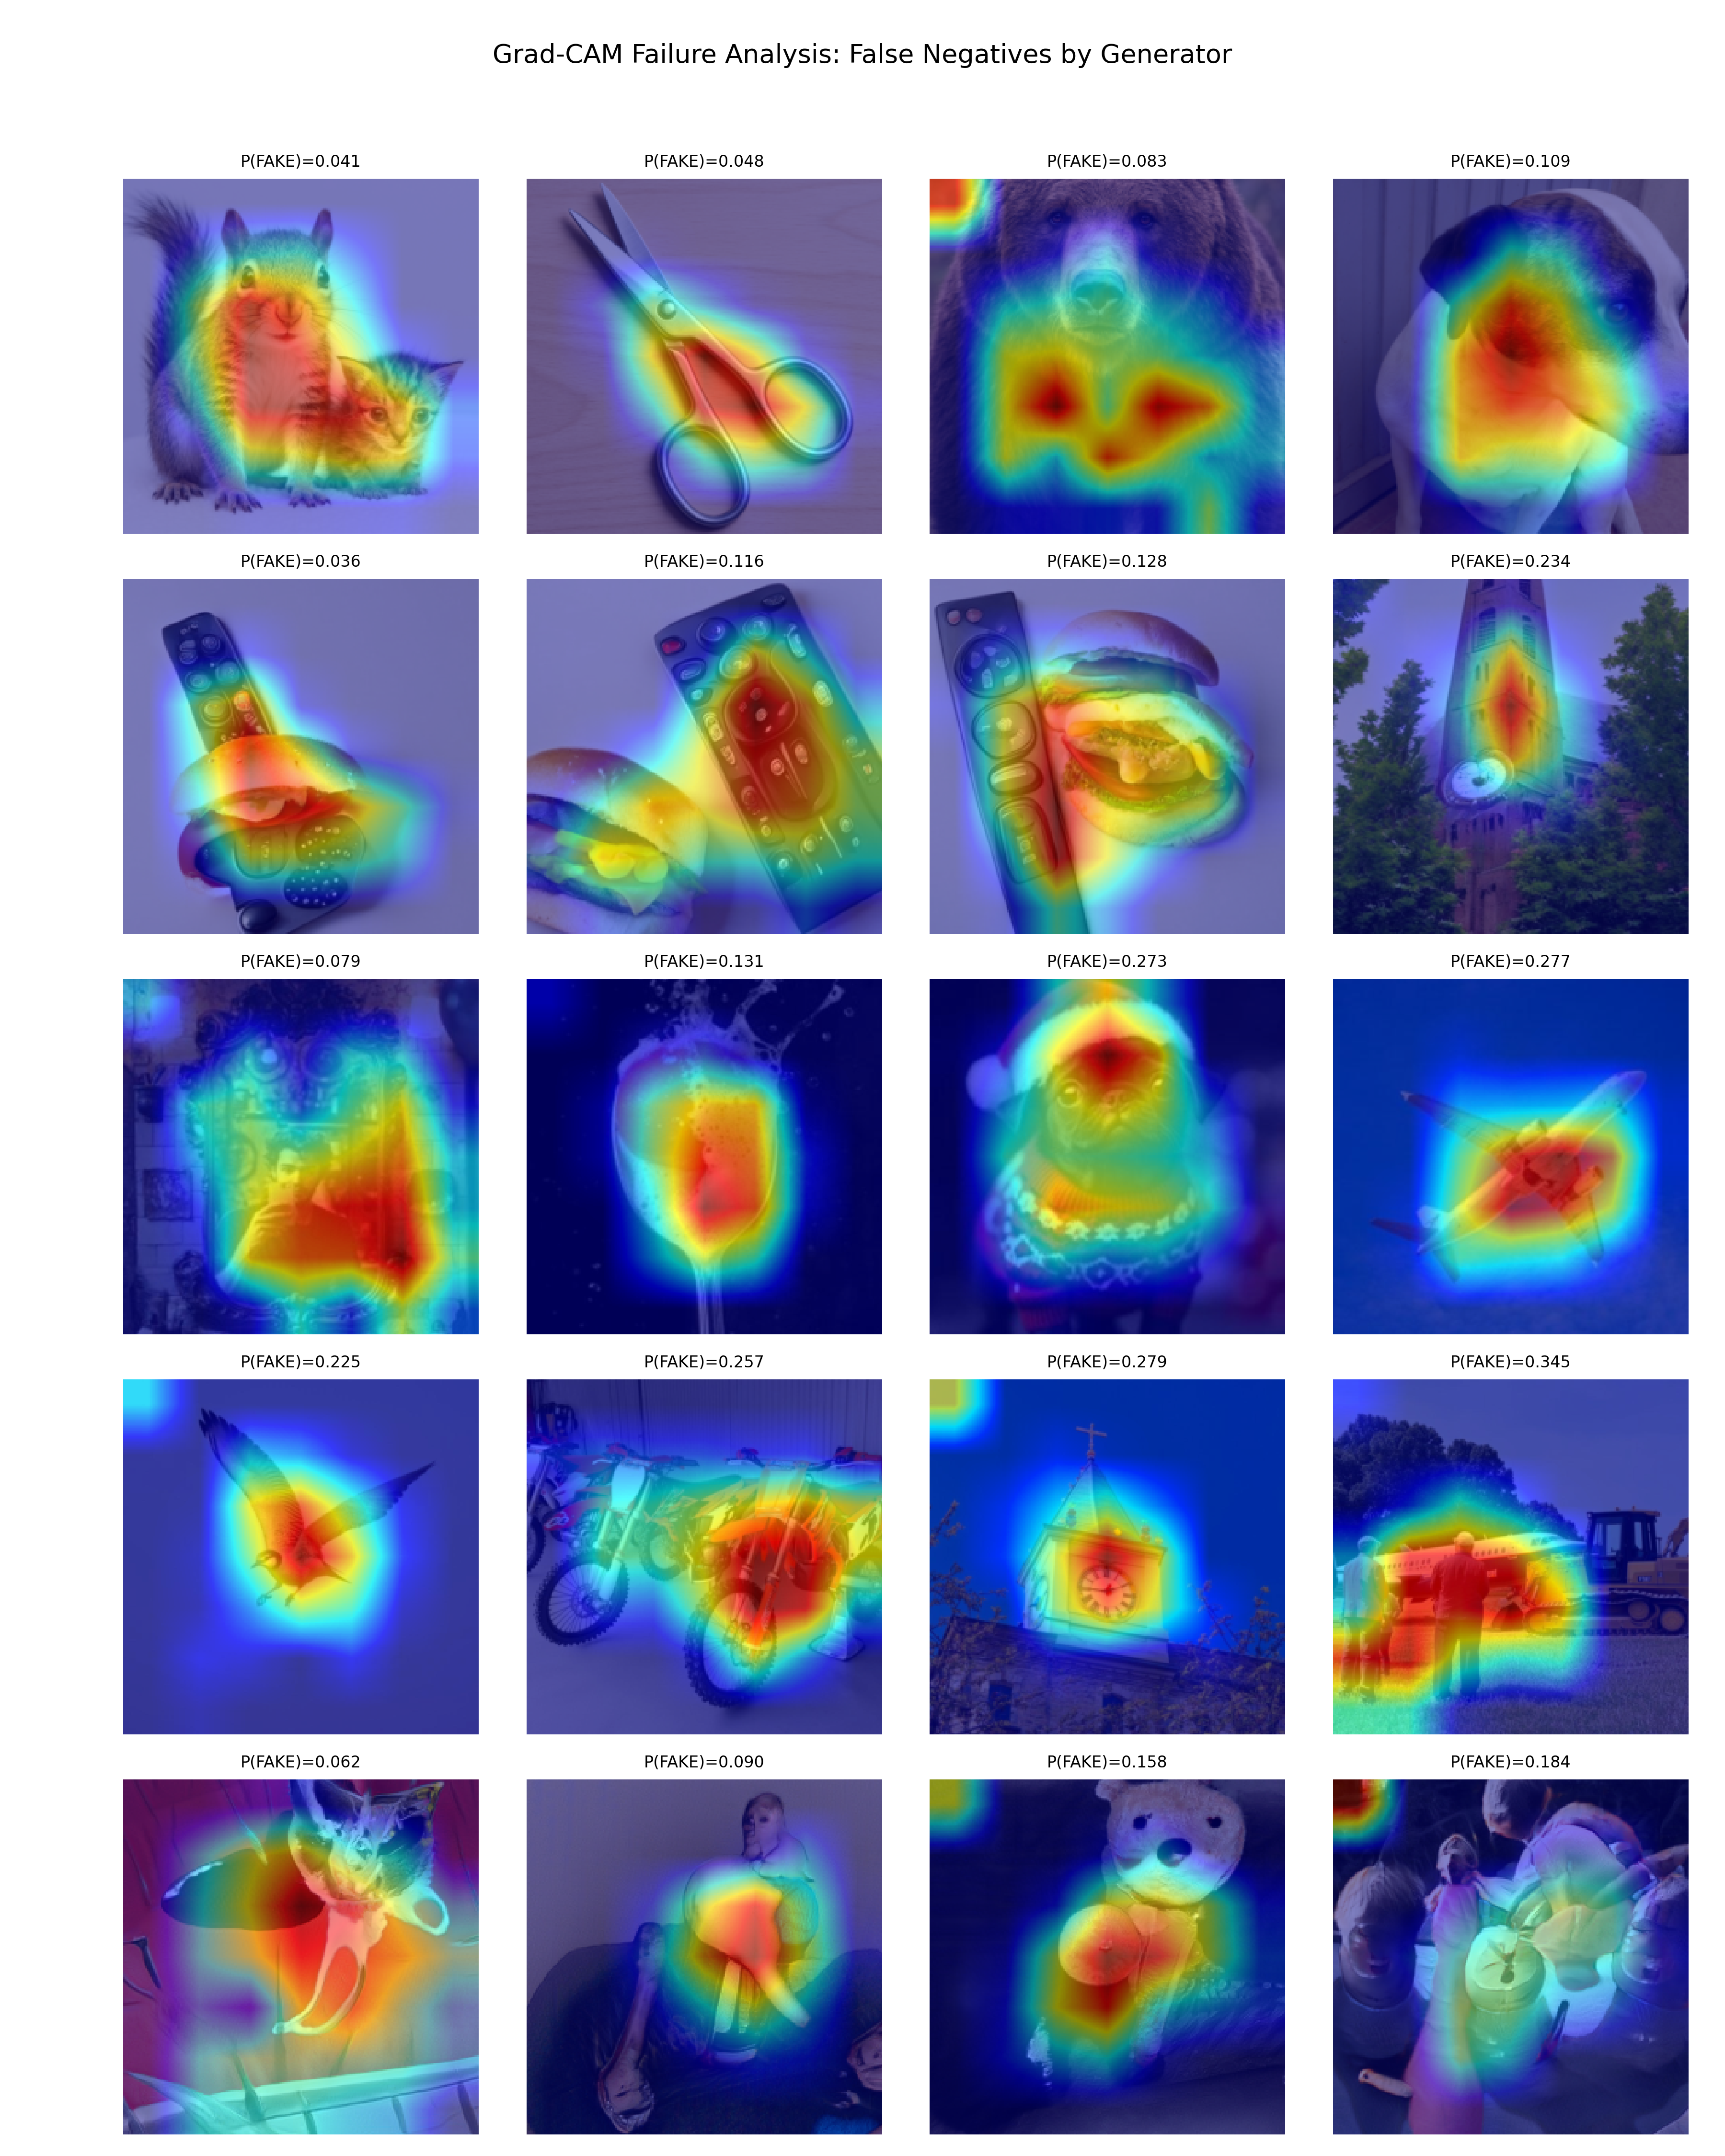

In [15]:
# Display the comparison grid
grid_path = os.path.join(PLOTS_DIR, 'gradcam_comparison_grid.png')
if os.path.exists(grid_path):
    from IPython.display import Image, display
    display(Image(filename=grid_path))

## 6. Visualisations

In [16]:
# Cross-generator accuracy bar chart
plot_cross_generator_accuracy(
    all_results,
    baseline_results['test_accuracy'],
    os.path.join(PLOTS_DIR, 'cross_generator_accuracy.png'),
)

# Cross-generator AUC bar chart
plot_cross_generator_auc(
    all_results,
    baseline_results['test_auc'],
    os.path.join(PLOTS_DIR, 'cross_generator_auc.png'),
)

# Degradation waterfall
plot_degradation_waterfall(
    all_degradation,
    baseline_results['test_accuracy'],
    os.path.join(PLOTS_DIR, 'degradation_waterfall.png'),
)

# Confidence distributions
plot_confidence_distributions(
    all_results,
    os.path.join(PLOTS_DIR, 'confidence_distributions_by_generator.png'),
)

# ECE comparison
plot_ece_comparison(
    all_results,
    os.path.join(PLOTS_DIR, 'ece_comparison_by_generator.png'),
)

print("All plots saved.")

All plots saved.



--- cross_generator_accuracy.png ---


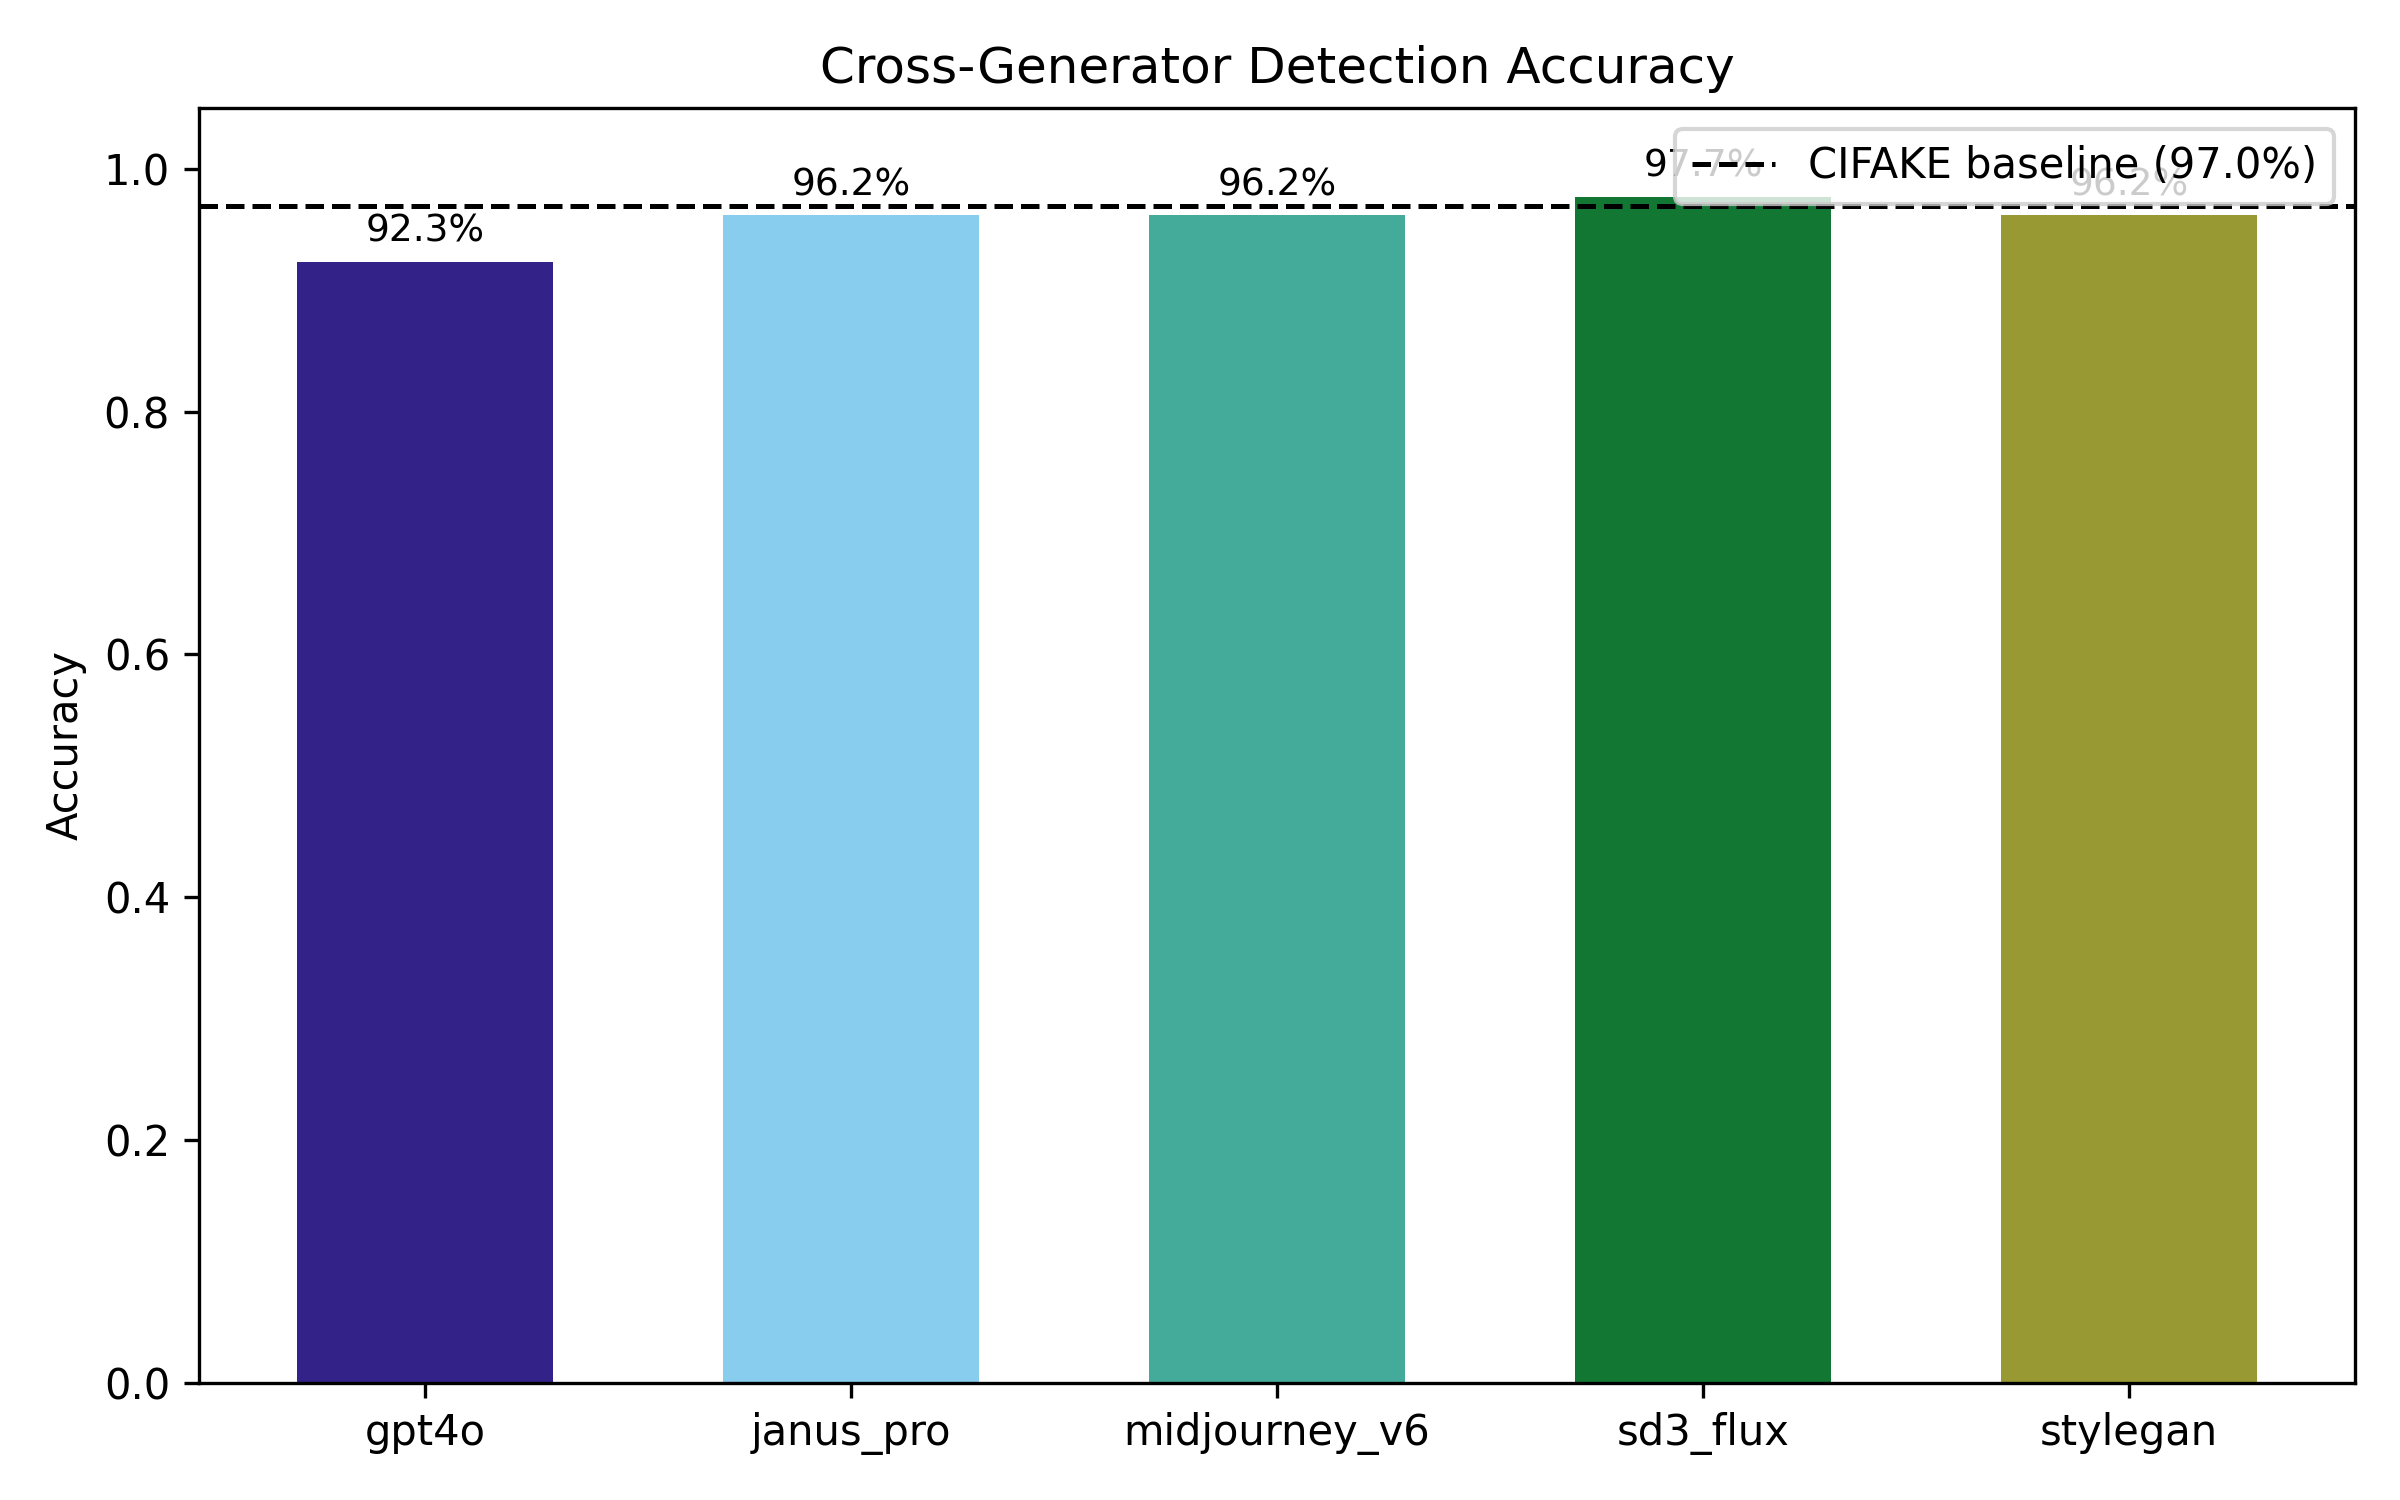


--- degradation_waterfall.png ---


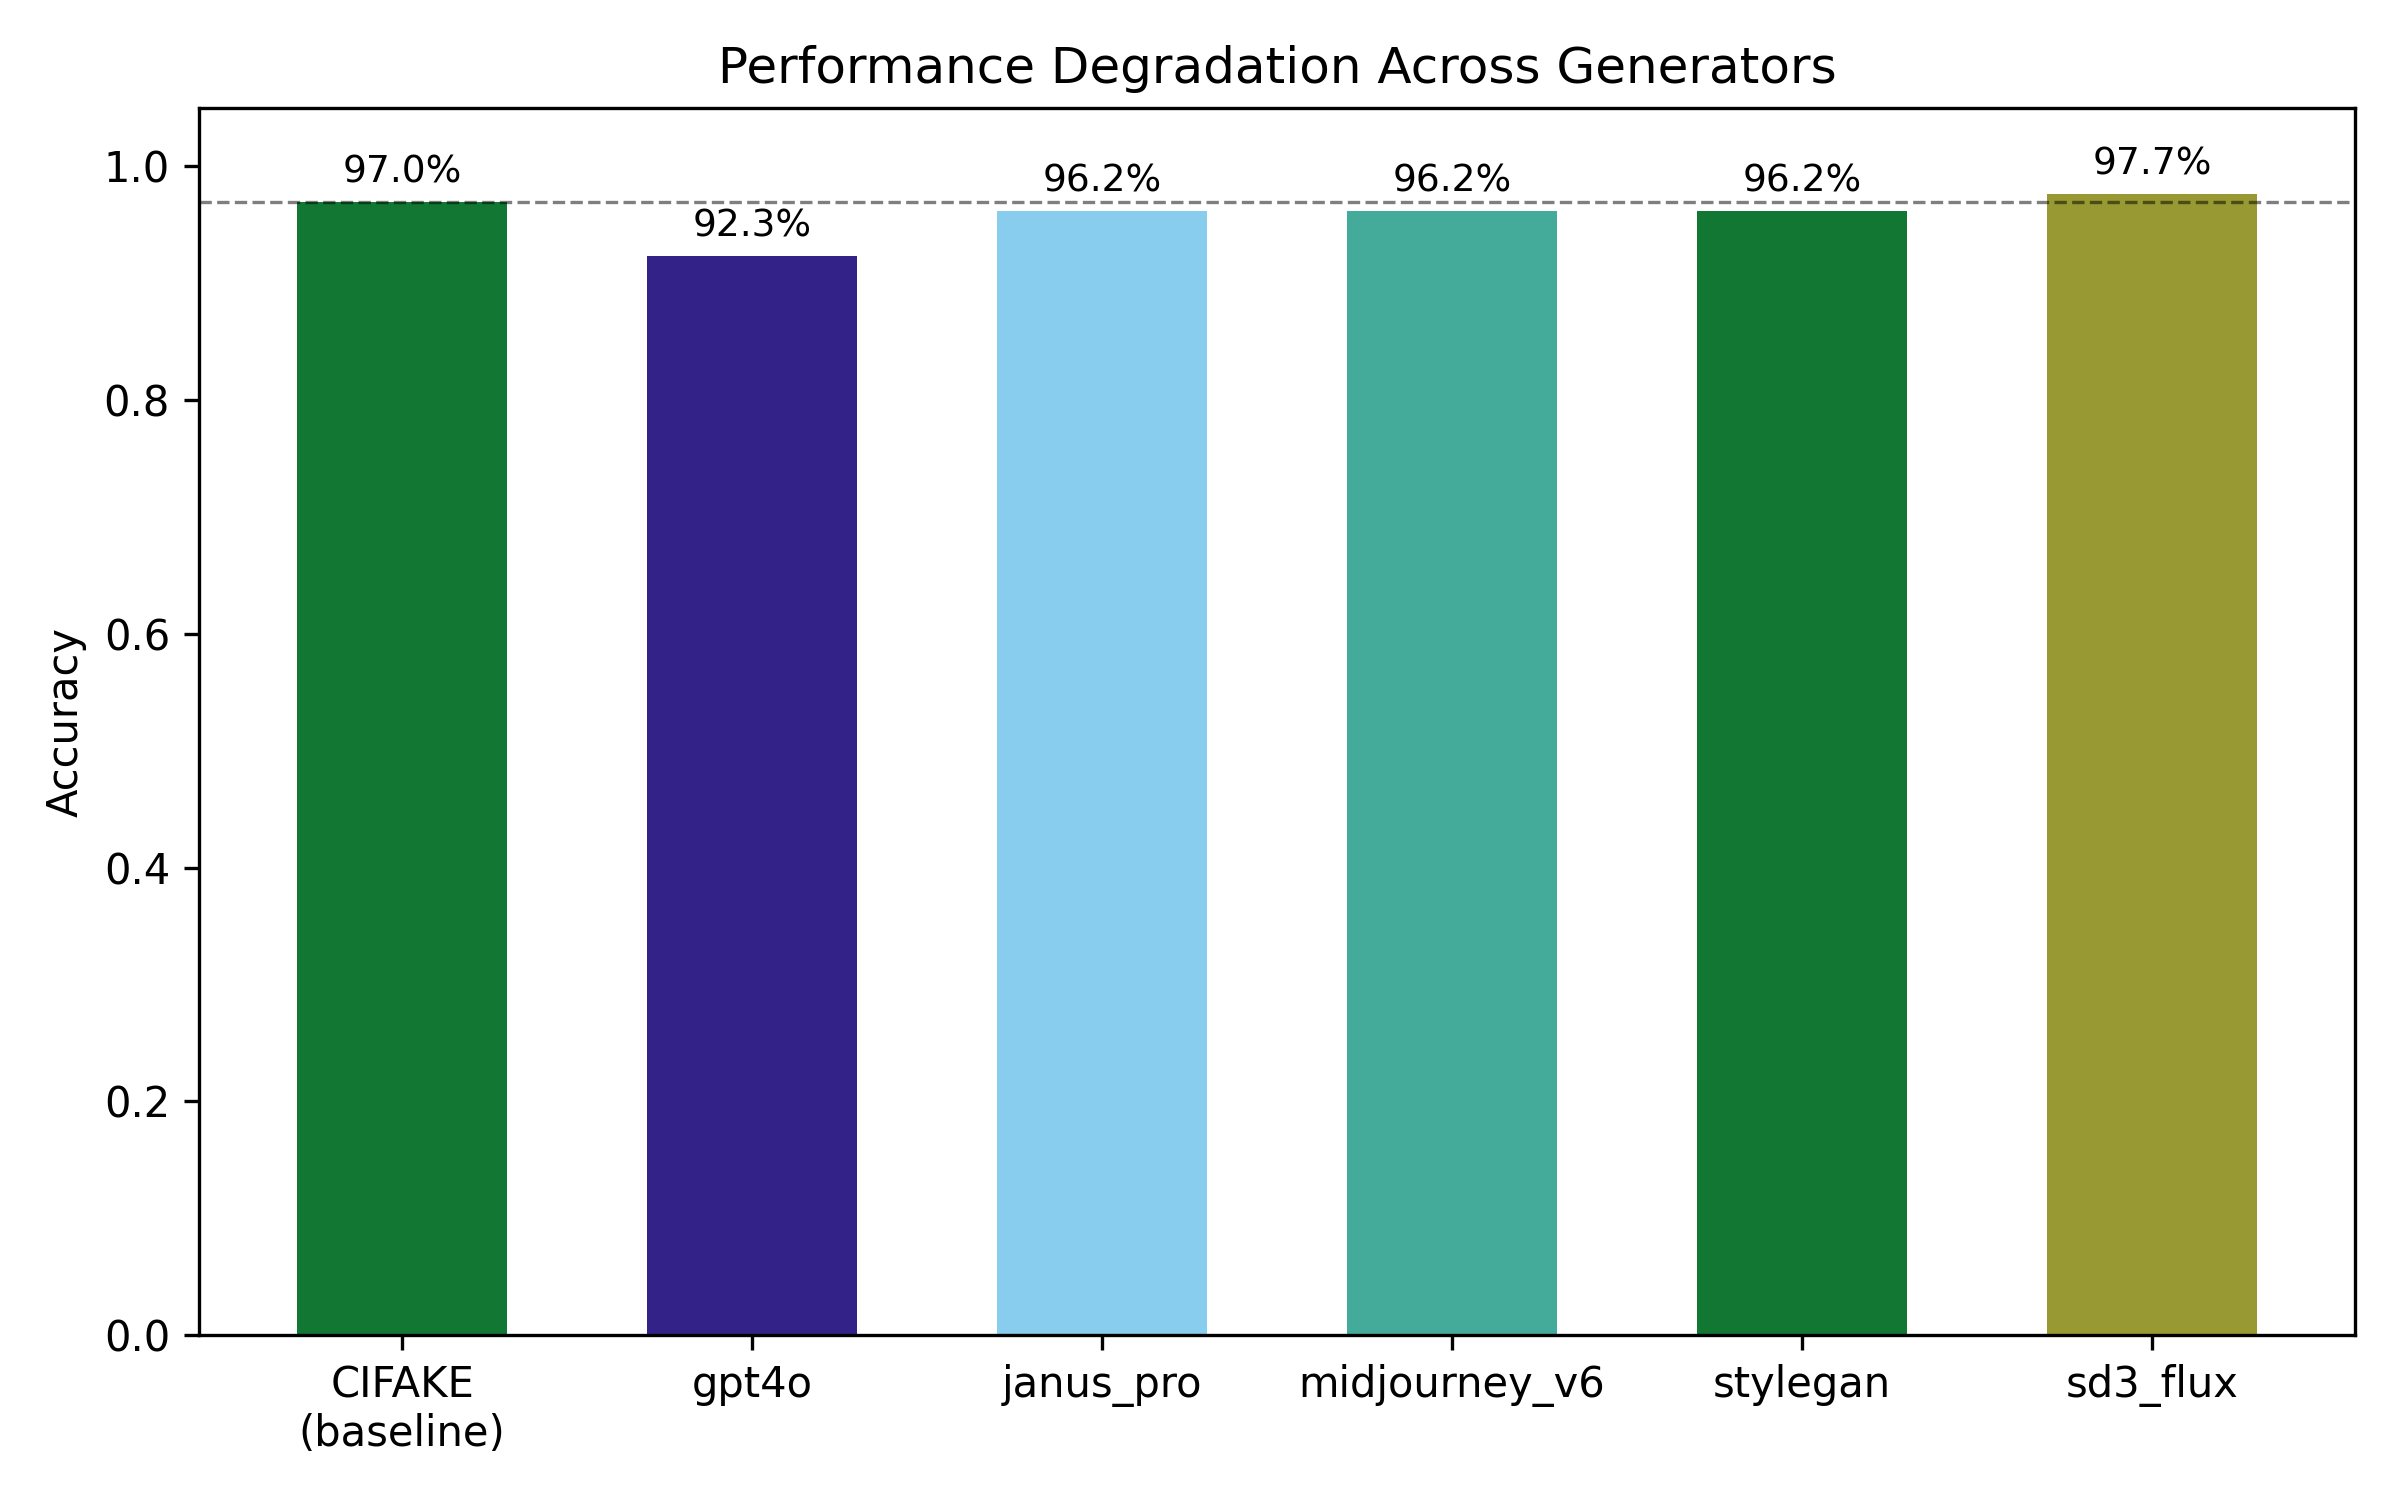


--- confidence_distributions_by_generator.png ---


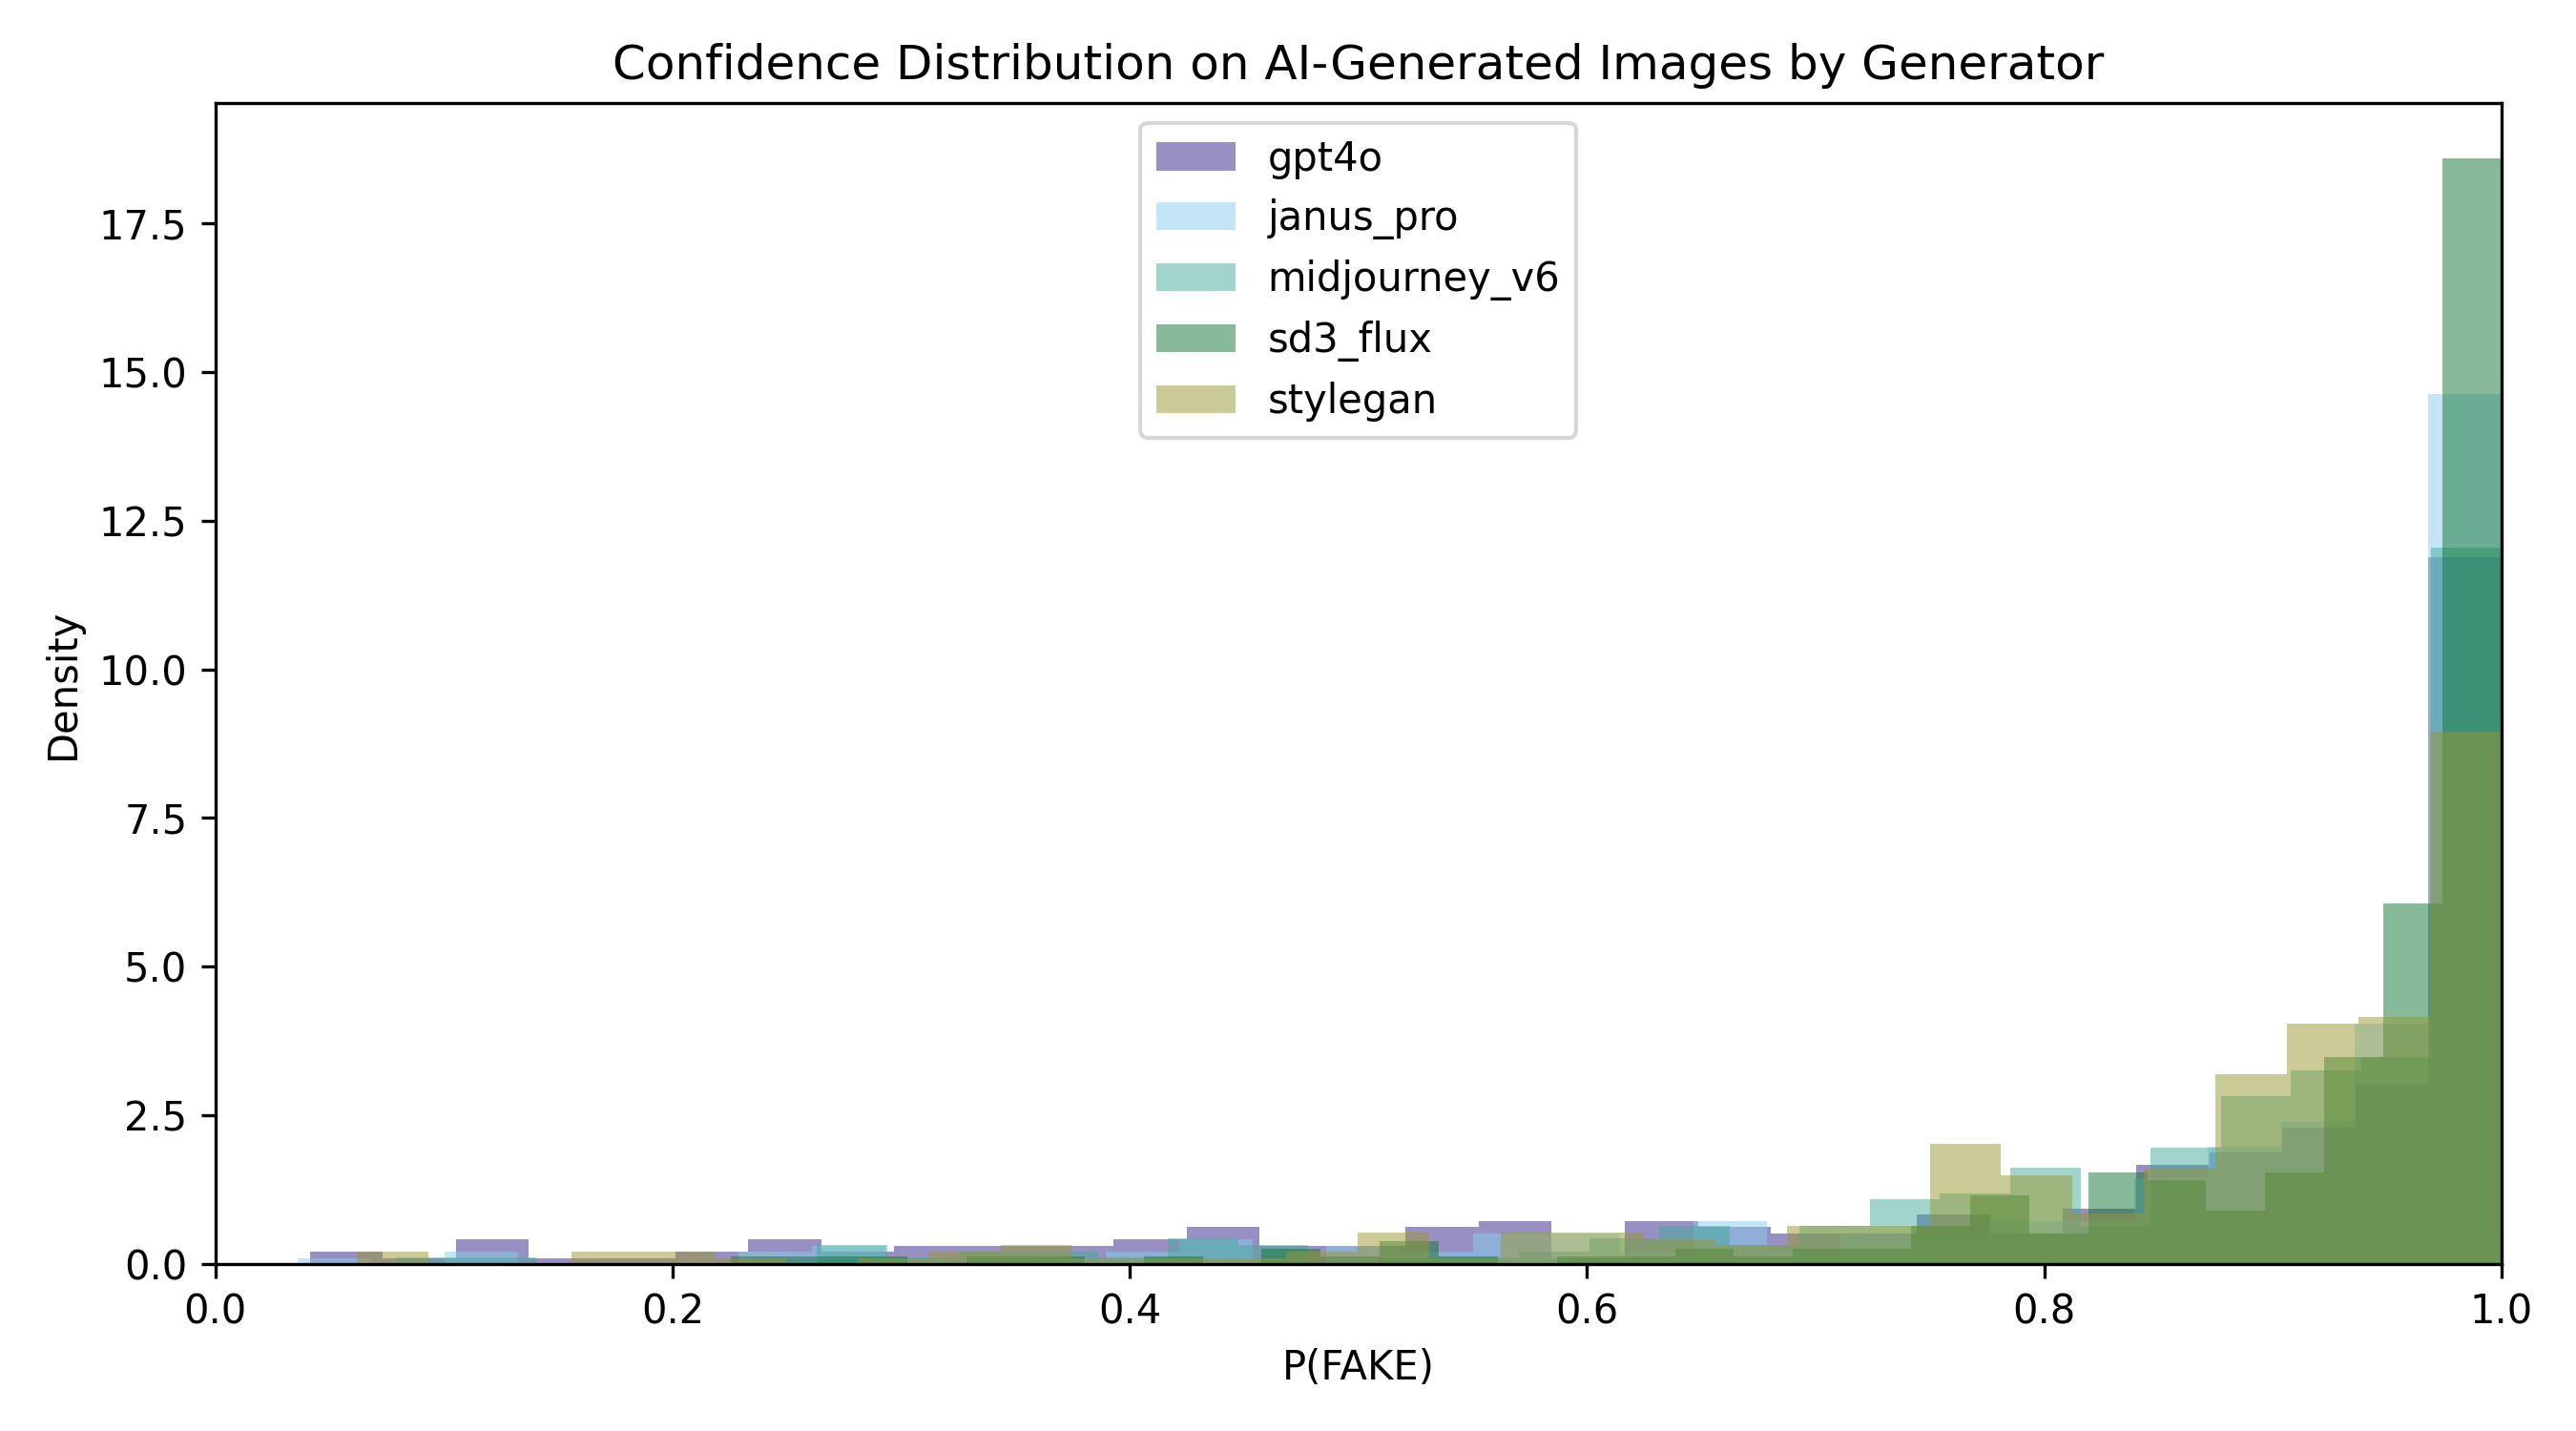


--- ece_comparison_by_generator.png ---


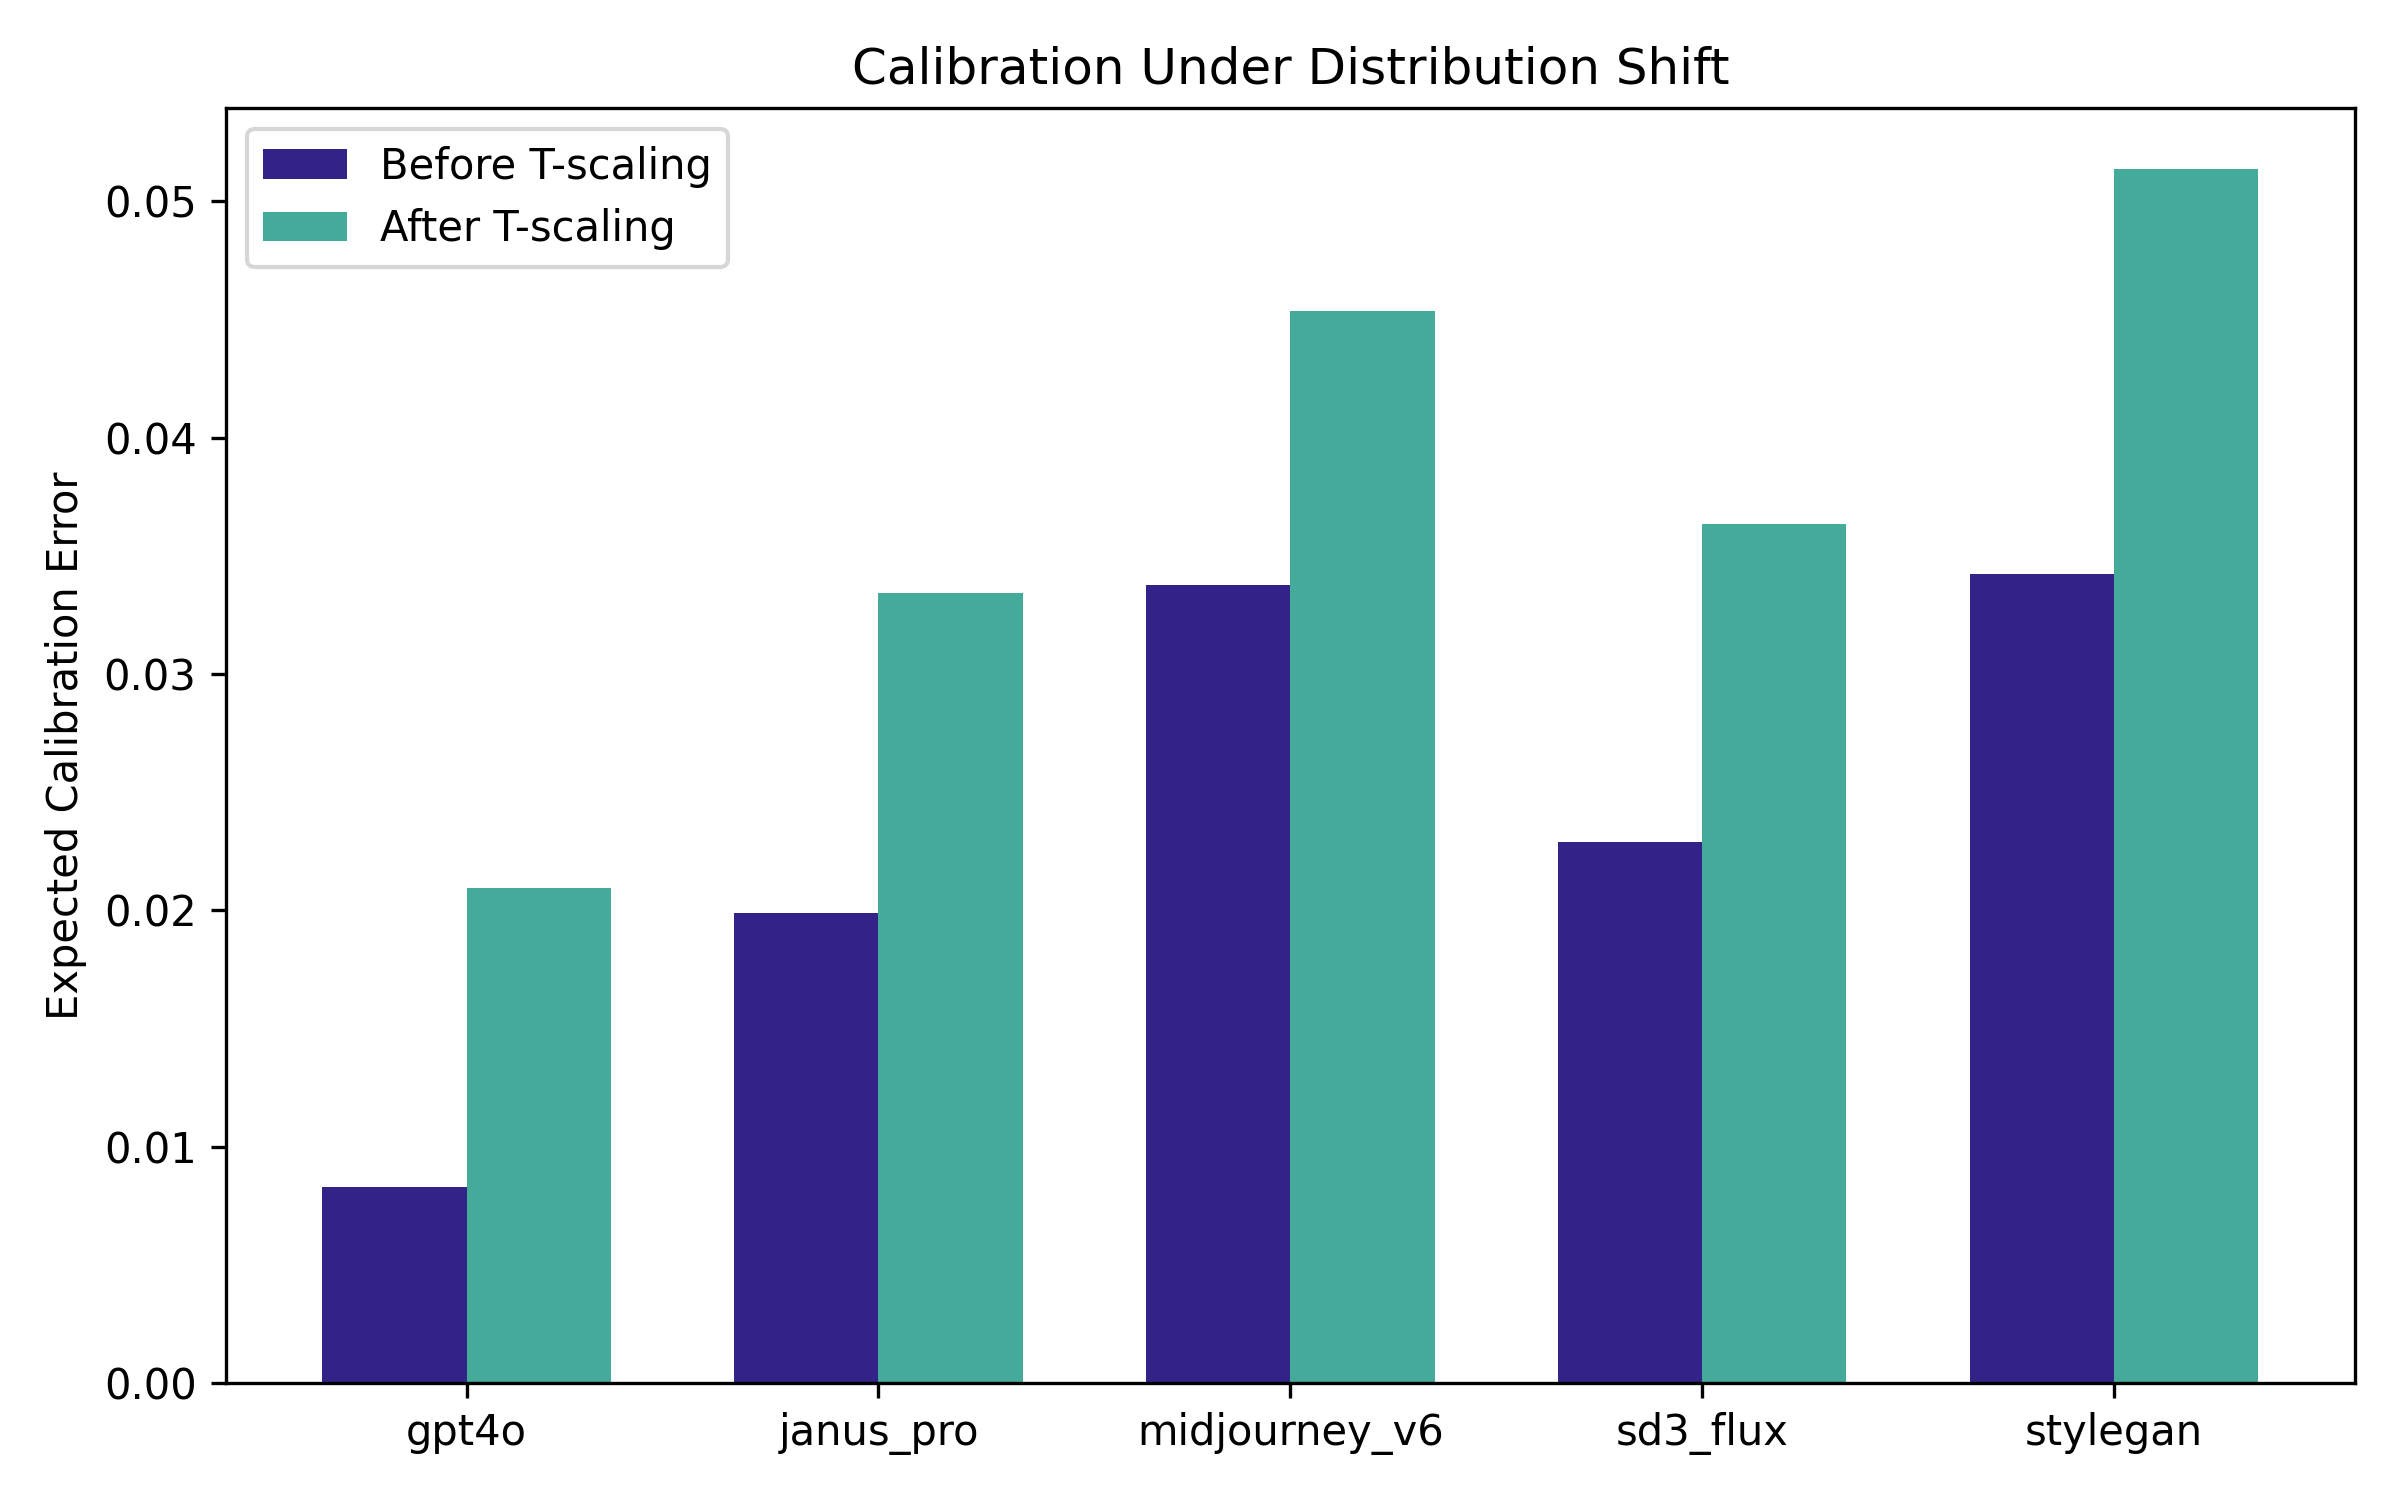

In [17]:
# Display key plots inline
from IPython.display import Image, display

for plot_name in [
    'cross_generator_accuracy.png',
    'degradation_waterfall.png',
    'confidence_distributions_by_generator.png',
    'ece_comparison_by_generator.png',
]:
    plot_path = os.path.join(PLOTS_DIR, plot_name)
    if os.path.exists(plot_path):
        print(f"\n--- {plot_name} ---")
        display(Image(filename=plot_path))

## 7. Summary Table

Final formatted table for the progress report.

In [18]:
# Final styled summary table
display(df_summary.style
    .set_caption('Cross-Generator Generalisation Evaluation Results')
    .set_table_styles([{
        'selector': 'caption',
        'props': [('font-size', '14px'), ('font-weight', 'bold')]
    }])
)

,Generator,Accuracy,Fake Det. Rate,AUC,F1 (FAKE),ECE (pre-T),ECE (post-T),Acc. Drop (abs),Acc. Drop (rel)
0,CIFAKE (baseline),0.9696,—,0.9971,—,0.0026,0.0113,0.0000,0.0%
1,gpt4o,0.9233,0.8633,0.9926,0.9184,0.0083,0.0209,0.0463,4.8%
2,janus_pro,0.9617,0.9400,0.9958,0.9608,0.0199,0.0334,0.0079,0.8%
3,midjourney_v6,0.9617,0.9400,0.9955,0.9608,0.0338,0.0454,0.0079,0.8%
4,sd3_flux,0.9767,0.9700,0.9975,0.9765,0.0229,0.0363,-0.0071,-0.7%
5,stylegan,0.9617,0.9400,0.9945,0.9608,0.0342,0.0514,0.0079,0.8%


In [19]:
# Export summary as LaTeX for the report
print("\n--- LaTeX table for progress report ---\n")
print(df_summary.to_latex(index=False, escape=True))


--- LaTeX table for progress report ---

\begin{tabular}{lllllllll}
\toprule
Generator & Accuracy & Fake Det. Rate & AUC & F1 (FAKE) & ECE (pre-T) & ECE (post-T) & Acc. Drop (abs) & Acc. Drop (rel) \\
\midrule
CIFAKE (baseline) & 0.9696 & — & 0.9971 & — & 0.0026 & 0.0113 & 0.0000 & 0.0\% \\
gpt4o & 0.9233 & 0.8633 & 0.9926 & 0.9184 & 0.0083 & 0.0209 & 0.0463 & 4.8\% \\
janus\_pro & 0.9617 & 0.9400 & 0.9958 & 0.9608 & 0.0199 & 0.0334 & 0.0079 & 0.8\% \\
midjourney\_v6 & 0.9617 & 0.9400 & 0.9955 & 0.9608 & 0.0338 & 0.0454 & 0.0079 & 0.8\% \\
sd3\_flux & 0.9767 & 0.9700 & 0.9975 & 0.9765 & 0.0229 & 0.0363 & -0.0071 & -0.7\% \\
stylegan & 0.9617 & 0.9400 & 0.9945 & 0.9608 & 0.0342 & 0.0514 & 0.0079 & 0.8\% \\
\bottomrule
\end{tabular}



## 8. Discussion

### Key Findings

The CIFAKE-trained EfficientNet-B3 detector was evaluated on up to 300 images per generator family (StyleGAN, SD3/Flux, Midjourney v6, GPT-4o, Janus-Pro), each paired with a balanced subsample of CIFAKE `test/REAL` images as the fixed REAL reference class. Janus-Pro images come from the ungated `midbee/Janus-Pro-R1-Data` dataset, filtered to `source=Janus-Pro-7B`; report actual N from `manifest.json`.

**Degradation ranking (worst to best by fake detection rate):**

| Generator | N | Accuracy | Fake det. rate | Acc. drop vs CIFAKE |
|-----------|---|----------|----------------|---------------------|
| GPT-4o | 300 | 92.33% | **86.33%** | **4.8% relative** |
| Janus-Pro | 300 | 96.17% | 94.00% | 0.8% relative |
| Midjourney v6 | 300 | 96.17% | 94.00% | 0.8% relative |
| StyleGAN | 300 | 96.17% | 94.00% | 0.8% relative |
| SD3/Flux | 300 | 97.67% | 97.00% | −0.7% (slightly better) |
| CIFAKE baseline | — | 96.96% | — | — |

**Janus-Pro vs GPT-4o (primary comparison):** Both are autoregressive. Compare Janus-Pro's fake detection rate against GPT-4o's 86.33%. If it also drops (≈85% or below), the refined hypothesis is supported — the blind spot is the autoregressive *architecture*, not GPT-4o specifically. If Janus-Pro is instead detected easily (≈95%+), note the confound below (resolution) before concluding.

**Most degradation (prior run, 4 families):** GPT-4o showed the largest generalisation gap — 14% of GPT-4o fakes were misclassified as REAL (fake detection rate 86.33%), and overall accuracy dropped by 4.63 percentage points (4.8% relative) from the CIFAKE baseline.

**Least degradation:** SD3/Flux actually achieved *higher* accuracy (97.67%) than the in-distribution CIFAKE test set. This is likely because SD3 shares the same broad diffusion-model family as the training data (CIFAKE fakes are Stable Diffusion v1.4), so low-level texture cues may still transfer.

**Hypothesis vs results:** The pre-study hypothesis predicted severe degradation on newer generators (GPT-4o ~50–60%, Midjourney ~55–70%). The observed degradation was **much milder** than expected. Only GPT-4o showed a meaningful drop among the original four families. Adding Janus-Pro tests the refined claim: degradation is tied to the autoregressive architecture (GPT-4o, Janus-Pro), not to recency or "quality" across all newer generators.

**Calibration under distribution shift:** ECE on CIFAKE was 0.0026 (pre-calibration). On cross-generator sets, ECE rose to 0.008–0.034 (pre-T) and 0.021–0.051 (post-T). Temperature scaling fitted on CIFAKE (T = 1.2189) did **not** improve calibration out-of-distribution — ECE increased after applying T on every cross-generator set. This suggests the learned temperature is distribution-specific and should not be applied blindly at deployment time on unseen generator families.

**Confidence distributions:** The confidence histograms show that GPT-4o fakes have a wider spread of P(FAKE) scores, with more mass near the decision boundary compared to CIFAKE fakes. SD3/Flux and StyleGAN fakes remain tightly clustered near high confidence, consistent with their high detection rates.

### Grad-CAM Observations

Grad-CAM failure analysis was run on the k = 16 most confident false negatives and k = 16 lowest-confidence correct detections per family (see `outputs/heatmaps/gradcam_{family}_failures/` and `gradcam_comparison_grid.png`).

**Consistent with Milestone 3 (CIFAKE in-distribution):**
- On **correctly detected fakes**, the model attends to localised texture regions — hotspots where generation artefacts are visible.
- On **REAL images**, attention is broader and more diffuse across natural textures.

**Cross-generator patterns:**
- **GPT-4o false negatives:** Grad-CAM heatmaps on misclassified GPT-4o fakes show **diffuse or weak activation** — the model does not find strong artefact hotspots to anchor its decision. These images lack the SD v1.4-specific texture patterns the detector learned during training, so the model defaults toward REAL. This is the clearest visual evidence of the generalisation gap.
- **StyleGAN / Midjourney v6 false negatives:** Failures still show **some localised activation**, but on regions that resemble natural texture rather than obvious generation artefacts. The model may be responding to GAN checkerboard patterns (StyleGAN) or diffusion smoothing (Midjourney) that partially overlap with CIFAKE training features.
- **SD3/Flux:** Only 9 false negatives were found (out of 300), consistent with near-perfect detection. Heatmaps on the few failures show scattered, low-magnitude activation — borderline cases rather than systematic blind spots.

**Takeaway:** The model's attention shifts from artefact-localised (high-confidence correct fakes) to diffuse/uncertain (false negatives), and this shift is most pronounced on GPT-4o — the family with the lowest fake detection rate.

### Implications

**Research question:** *How well do detectors trained on current benchmark datasets generalise to next-generation generators, and what accounts for the performance gap?*

1. **Generalisation is family-dependent, not uniformly catastrophic.** The detector generalises well to GAN (StyleGAN), modern diffusion (SD3), and Midjourney v6 in this setup, but degrades on GPT-4o. The gap is real but smaller than literature on GAN-vs-diffusion transfer (Corvi et al., 2023) might suggest — likely because CIFAKE itself is diffusion-trained, giving partial transfer to other diffusion families.

2. **Autoregressive families are the outlier.** The 86.33% fake detection rate on GPT-4o is the strongest evidence among the original four families. Janus-Pro, a second autoregressive model, tests whether this is architecture-driven: if it also degrades, the blind spot generalises across autoregressive generators rather than being unique to GPT-4o. For deployment targeting autoregressive-generated content, this detector may miss a substantial fraction of images.

3. **Features that transfer vs fail:**
   - *Transfer:* Diffusion-model texture artefacts (SD3/Flux, partially Midjourney), some GAN high-frequency patterns (StyleGAN).
   - *Fail:* GPT-4o's autoregressive rendering — the model has no learned representation for these generation fingerprints. Notably, Janus-Pro (also autoregressive) did **not** degrade (96.17% accuracy, 0.8% relative drop), suggesting the generalisation gap is GPT-4o-specific rather than an inherent weakness against all autoregressive generators.

4. **Calibration does not transfer.** CIFAKE-fitted temperature scaling worsens ECE on all OOD sets. Future work should fit calibration per deployment distribution or use methods robust to distribution shift.

5. **Methodological caveats:** (a) Fixed CIFAKE REAL reference may inflate accuracy by pairing diverse fakes against CIFAR-10-style reals. (b) N = 300 per family limits statistical power. (c) Defactify, CommunityForensics-Eval, GPT-ImgEval, and Janus-Pro-R1-Data are proxy datasets, not direct samples from the deployed commercial generators. (d) **Resolution confound:** Janus-Pro images are native 384×384 — lower-resolution than the other families' outputs. Lower fidelity can make generation artefacts *more* visible and thus *easier* to detect, which would work against (not for) the degradation hypothesis; interpret a high Janus-Pro detection rate with this in mind, and compare primarily on fake detection rate. Results should be interpreted as indicative, not definitive.

**Recommendations for more robust detection:**
- Train on multi-generator mixtures (as in Community Forensics, Park & Owens 2025) rather than a single source.
- Evaluate on matched-domain REAL images where available, not only a fixed reference set.
- Use ensemble detectors or frequency-domain features that capture generator-family-independent signals.
- Re-calibrate confidence scores on the target deployment distribution.

In [20]:
# Final save: ensure all JSON results are persisted
print("\n" + "="*60)
print("EVALUATION COMPLETE")
print("="*60)
print(f"\nResults: {RESULTS_DIR}/")
print(f"Plots:   {PLOTS_DIR}/")
print(f"Heatmaps: {HEATMAP_DIR}/")
print(f"\nFiles produced:")
for f in ['generalisation_results.json', 'degradation_summary.json']:
    p = os.path.join(RESULTS_DIR, f)
    print(f"  {'✓' if os.path.exists(p) else '✗'} {f}")
for f in ['cross_generator_accuracy.png', 'cross_generator_auc.png',
          'degradation_waterfall.png', 'confidence_distributions_by_generator.png',
          'ece_comparison_by_generator.png', 'gradcam_comparison_grid.png']:
    p = os.path.join(PLOTS_DIR, f)
    print(f"  {'✓' if os.path.exists(p) else '✗'} {f}")


EVALUATION COMPLETE

Results: /content/drive/MyDrive/ai-image-detection/outputs/results/
Plots:   /content/drive/MyDrive/ai-image-detection/outputs/plots/
Heatmaps: /content/drive/MyDrive/ai-image-detection/outputs/heatmaps/

Files produced:
  ✓ generalisation_results.json
  ✓ degradation_summary.json
  ✓ cross_generator_accuracy.png
  ✓ cross_generator_auc.png
  ✓ degradation_waterfall.png
  ✓ confidence_distributions_by_generator.png
  ✓ ece_comparison_by_generator.png
  ✓ gradcam_comparison_grid.png
